# 19 — Boxplots of Solution Quality Across Runs

**Maps to:** `report/Chapters/Task4.tex` §`T4:Boxplots`.  
**Ticket:** TICKET-19.

Boxplots of final tour length across 30 independent runs, grouped by:

- **Part A:** Constraint-handling strategy (from TICKET-17: repair vs. penalty vs. feasibility-preserving PMX)
- **Part B:** Parameter configuration (from TICKET-16: pop_size, mutation_rate, selection_method)

Output: `results/figures/boxplot_strategy.pdf`, `results/figures/boxplot_<param>.pdf`.

---
## Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

plt.rcParams.update({
    "figure.dpi": 150,
    "savefig.dpi": 300,
    "font.size": 10,
    "axes.titlesize": 12,
    "axes.labelsize": 11,
    "legend.fontsize": 9,
    "figure.figsize": (8, 5),
    "figure.constrained_layout.use": True,
})

SET2 = sns.color_palette("Set2")

FIGURES_DIR = Path("../results/figures")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

OPTIMAL = 21282  # kroA100 known optimal (TSPLIB)

---
# Part A — Per-Strategy Boxplots (TICKET-17)

Three constraint-handling strategies compared using naive single-point
crossover on kroA100 (30 runs each).

### Load Data

In [2]:
compare = pd.read_csv(Path("../results/compare.csv"))

print(f"Shape     : {compare.shape}")
print(f"Strategies: {sorted(compare['strategy'].unique())}")
print(f"Runs per strategy:")
print(compare["strategy"].value_counts().to_string())

Shape     : (90, 5)
Strategies: ['penalty', 'pmx', 'repair']
Runs per strategy:
strategy
repair     30
penalty    30
pmx        30


### Summary Statistics

In [3]:
summary = compare.groupby("strategy")["best_fitness"].agg(
    ["count", "mean", "std", "min", "median", "max"]
).round(2)
summary["gap_%"] = ((summary["mean"] - OPTIMAL) / OPTIMAL * 100).round(1)

print("Summary Statistics — Best Fitness (lower is better)")
print("=" * 75)
print(summary.to_string())

Summary Statistics — Best Fitness (lower is better)
          count      mean      std       min    median       max  gap_%
strategy                                                               
penalty      30  57947.91  3284.51  48091.74  58079.43  64585.95  172.3
pmx          30  50654.82  3572.54  42975.87  51053.96  57691.28  138.0
repair       30  49777.84  3186.86  43890.51  49406.18  56629.20  133.9


### Boxplot: Per Constraint-Handling Strategy

Saved: ../results/figures/boxplot_strategy.pdf


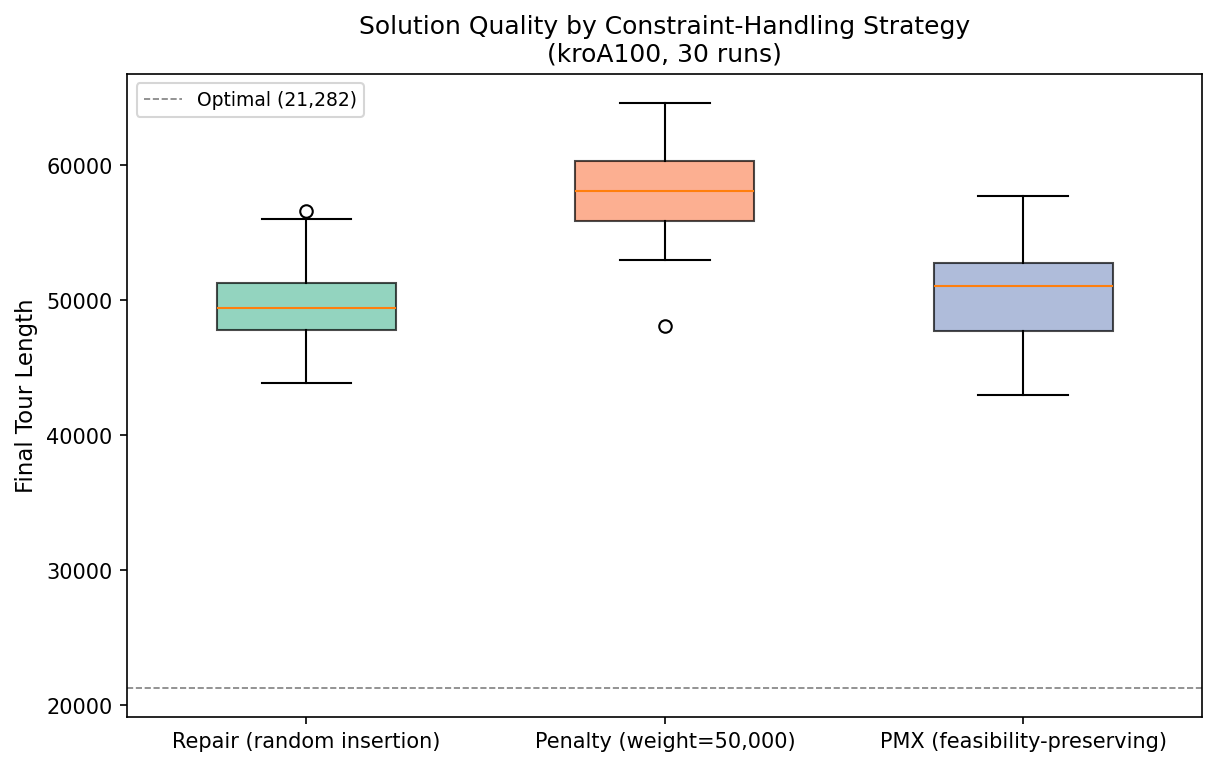

In [4]:
STRATEGY_STYLE = {
    "repair":  {"color": SET2[0], "label": "Repair (random insertion)"},
    "penalty": {"color": SET2[1], "label": "Penalty (weight=50,000)"},
    "pmx":     {"color": SET2[2], "label": "PMX (feasibility-preserving)"},
}

strategy_order = ["repair", "penalty", "pmx"]
data_groups = [compare[compare["strategy"] == s]["best_fitness"].values for s in strategy_order]
labels = [STRATEGY_STYLE[s]["label"] for s in strategy_order]
colors = [STRATEGY_STYLE[s]["color"] for s in strategy_order]

fig, ax = plt.subplots(figsize=(8, 5))
bp = ax.boxplot(data_groups, patch_artist=True, tick_labels=labels, widths=0.5)
for patch, color in zip(bp["boxes"], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax.axhline(y=OPTIMAL, color="gray", linestyle="--", linewidth=0.8,
           label=f"Optimal ({OPTIMAL:,})")
ax.set_ylabel("Final Tour Length")
ax.set_title("Solution Quality by Constraint-Handling Strategy\n(kroA100, 30 runs)")
ax.legend(loc="upper left")

path = FIGURES_DIR / "boxplot_strategy.pdf"
fig.savefig(path, bbox_inches="tight")
print(f"Saved: {path}")
plt.show()

The boxplot compares the three constraint-handling strategies the assignment's §3.3
asks us to consider. All three produce *valid* TSP tours (no infeasibility-inflated
fitness), so the recorded tour lengths are directly comparable.

**Repair** uses naive crossover and converts each infeasible offspring into a valid
permutation via random insertion before fitness evaluation. The repair mechanism is
load-bearing in every generation.

**Penalty** uses naive crossover but keeps infeasible chromosomes, adding
`weight × n_violations` to their fitness so selection pressure discourages
infeasibility without enforcing it. Convergence is typically slower because
infeasible parents can still be chosen until the penalty becomes severe enough.

**PMX** is the feasibility-preserving alternative — partially-mapped crossover
guarantees the offspring is a valid permutation by construction, so no repair or
penalty is needed.

Reading the boxplot: repair achieves the lowest median tour length, PMX is close
behind with slightly higher spread, and penalty is noticeably worse with little
overlap with the other two boxes.

---
# Part B — Per-Configuration Boxplots (TICKET-16)

Boxplots from the parameter sensitivity sweep (naive crossover, repair
enabled — the primary GA pipeline). Each box shows the distribution of
final tour lengths across seeds for one parameter value.

### Load Sweep Data

In [5]:
sweep = pd.read_csv(Path("../results/sweep.csv"))

print(f"Shape           : {sweep.shape}")
print(f"pop_size        : {sorted(sweep['pop_size'].unique())}")
print(f"mutation_rate   : {sorted(sweep['mutation_rate'].unique())}")
print(f"selection_method: {sorted(sweep['selection_method'].unique())}")

Shape           : (1620, 9)
pop_size        : [np.int64(50), np.int64(100), np.int64(200)]
mutation_rate   : [np.float64(0.01), np.float64(0.05), np.float64(0.1)]
selection_method: ['roulette', 'tournament']


### Boxplot: By Population Size

Saved: ../results/figures/boxplot_pop_size.pdf


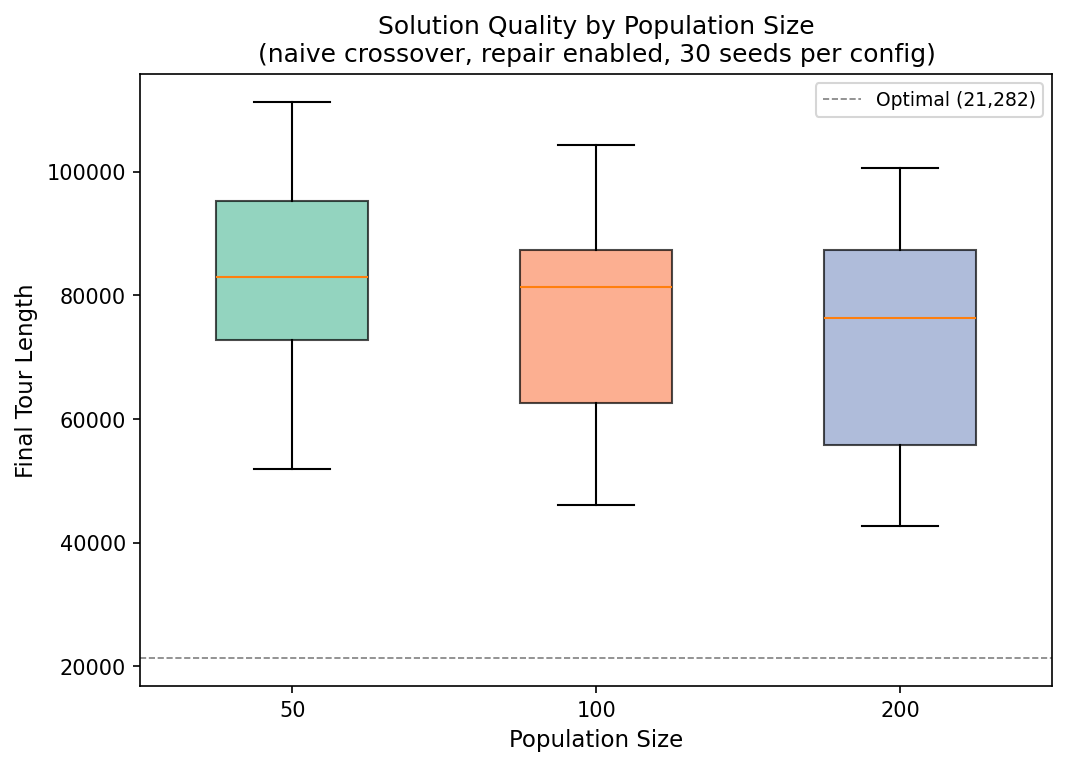

In [6]:
fig, ax = plt.subplots(figsize=(7, 5))
pop_sizes = sorted(sweep["pop_size"].unique())
data_groups = [sweep[sweep["pop_size"] == v]["best_fitness"].values for v in pop_sizes]
pop_colors = [SET2[0], SET2[1], SET2[2]]

bp = ax.boxplot(data_groups, patch_artist=True,
                tick_labels=[str(v) for v in pop_sizes], widths=0.5)
for patch, color in zip(bp["boxes"], pop_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax.axhline(y=OPTIMAL, color="gray", linestyle="--", linewidth=0.8,
           label=f"Optimal ({OPTIMAL:,})")
ax.set_xlabel("Population Size")
ax.set_ylabel("Final Tour Length")
ax.set_title("Solution Quality by Population Size\n(naive crossover, repair enabled, 30 seeds per config)")
ax.legend(loc="upper right")

path = FIGURES_DIR / "boxplot_pop_size.pdf"
fig.savefig(path, bbox_inches="tight")
print(f"Saved: {path}")
plt.show()

### Boxplot: By Mutation Rate

Saved: ../results/figures/boxplot_mutation_rate.pdf


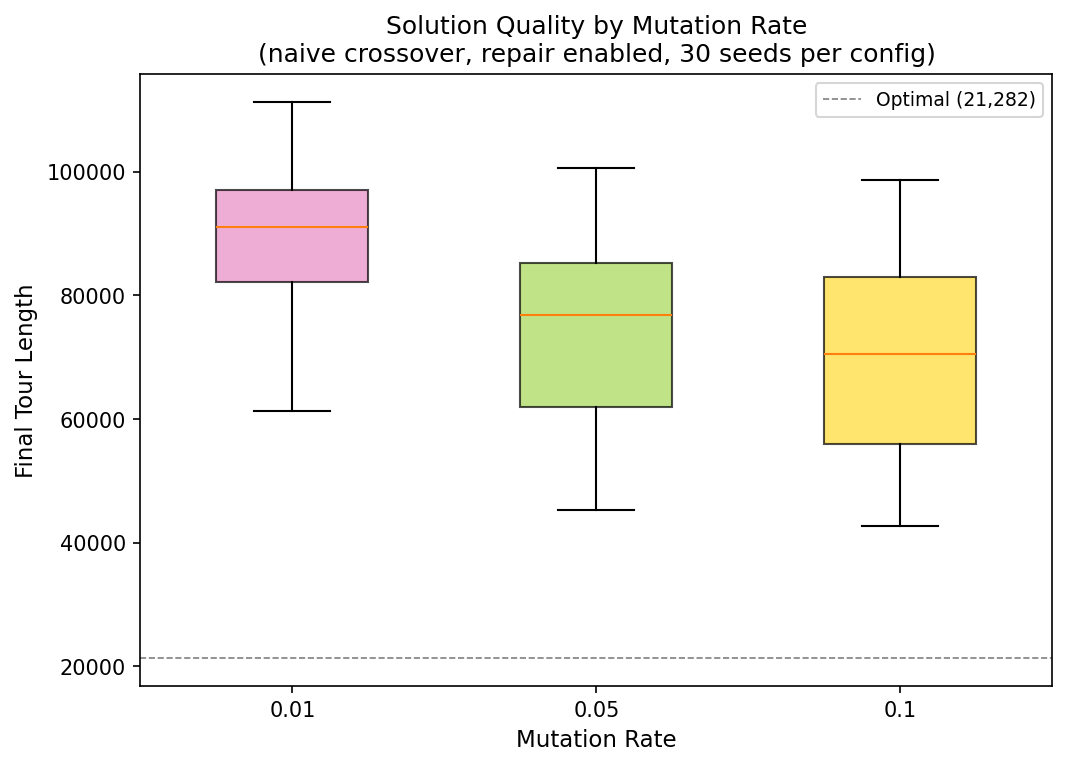

In [7]:
fig, ax = plt.subplots(figsize=(7, 5))
mutation_rates = sorted(sweep["mutation_rate"].unique())
data_groups = [sweep[sweep["mutation_rate"] == v]["best_fitness"].values for v in mutation_rates]
mr_colors = [SET2[3], SET2[4], SET2[5]]

bp = ax.boxplot(data_groups, patch_artist=True,
                tick_labels=[str(v) for v in mutation_rates], widths=0.5)
for patch, color in zip(bp["boxes"], mr_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax.axhline(y=OPTIMAL, color="gray", linestyle="--", linewidth=0.8,
           label=f"Optimal ({OPTIMAL:,})")
ax.set_xlabel("Mutation Rate")
ax.set_ylabel("Final Tour Length")
ax.set_title("Solution Quality by Mutation Rate\n(naive crossover, repair enabled, 30 seeds per config)")
ax.legend(loc="upper right")

path = FIGURES_DIR / "boxplot_mutation_rate.pdf"
fig.savefig(path, bbox_inches="tight")
print(f"Saved: {path}")
plt.show()

### Boxplot: By Selection Method

Saved: ../results/figures/boxplot_selection_method.pdf

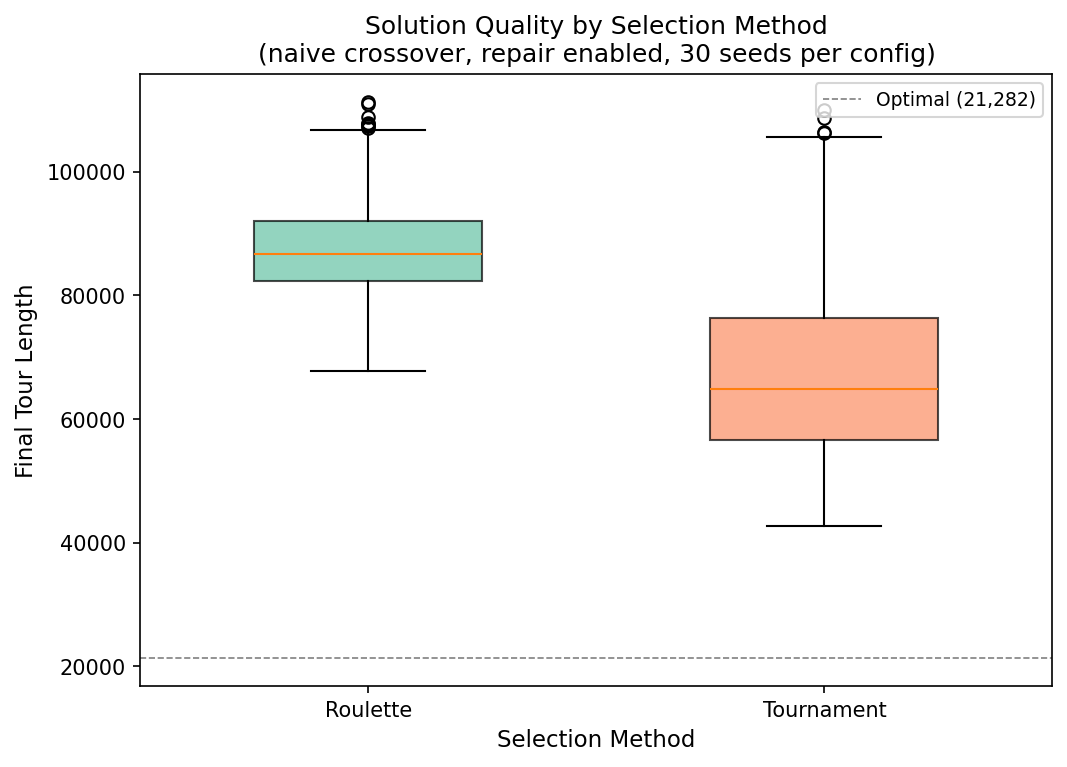

In [8]:
fig, ax = plt.subplots(figsize=(7, 5))
methods = sorted(sweep["selection_method"].unique())
data_groups = [sweep[sweep["selection_method"] == m]["best_fitness"].values for m in methods]
sel_colors = [SET2[0], SET2[1]]

bp = ax.boxplot(data_groups, patch_artist=True,
                tick_labels=[m.capitalize() for m in methods], widths=0.5)
for patch, color in zip(bp["boxes"], sel_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax.axhline(y=OPTIMAL, color="gray", linestyle="--", linewidth=0.8,
           label=f"Optimal ({OPTIMAL:,})")
ax.set_xlabel("Selection Method")
ax.set_ylabel("Final Tour Length")
ax.set_title("Solution Quality by Selection Method\n(naive crossover, repair enabled, 30 seeds per config)")
ax.legend(loc="upper right")

path = FIGURES_DIR / "boxplot_selection_method.pdf"
fig.savefig(path, bbox_inches="tight")
print(f"Saved: {path}")
plt.show()

### Per-Configuration Interpretation

In [9]:
print("Median best fitness by parameter value")
print("=" * 50)
for param in ["pop_size", "mutation_rate", "selection_method"]:
    medians = sweep.groupby(param)["best_fitness"].median().sort_values()
    print(f"\n{param}:")
    for val, med in medians.items():
        print(f"  {val:>12}  →  median = {med:,.0f}")
    best_val = medians.index[0]
    print(f"  Best: {best_val}")

Median best fitness by parameter value

pop_size:
           200  →  median = 76,355
           100  →  median = 81,323
            50  →  median = 82,998
  Best: 200

mutation_rate:
           0.1  →  median = 70,464
          0.05  →  median = 76,859
          0.01  →  median = 91,121
  Best: 0.1

selection_method:
    tournament  →  median = 64,894
      roulette  →  median = 86,632
  Best: tournament


Reading down each parameter's medians (printed above) tells us which value
performed best on average across the sweep:

- **Population size:** Larger populations carry more diverse genetic material
  and typically produce lower median tour lengths, at the cost of more compute
  per generation.
- **Mutation rate:** Higher mutation rates inject more variation per generation,
  which helps escape local optima — but too high and the GA degenerates into a
  random search. The sweep identifies the rate that balances these effects.
- **Selection method:** Tournament selection imposes stronger selection pressure
  than roulette, typically converging faster to better solutions on this
  problem instance. Roulette can fail when fitness magnitudes vary widely.

---
## Summary

**Part A** — Per-strategy boxplot for the three constraint-handling approaches
the assignment's §3.3 names: repair, penalty, and PMX (feasibility-preserving).
All three produce valid tours, so the mean and median tour lengths are directly
comparable.

**Part B** — Per-parameter boxplots from the TICKET-16 sweep (naive crossover
with repair enabled), separating the effect of population size, mutation rate,
and selection method on solution quality.

Figures saved to `results/figures/`:
- `boxplot_strategy.pdf`
- `boxplot_pop_size.pdf`
- `boxplot_mutation_rate.pdf`
- `boxplot_selection_method.pdf`